# Hierarchical Clustering

**Topic:** Unsupervised Learning — Clustering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, set_link_color_palette
from scipy.spatial.distance import pdist
from tkh_utils import PALETTE


---
## What you'll explore

By the end of this demo you will be able to:

- **Describe** how agglomerative clustering builds a tree of merges from N clusters to 1
- **Explain** how linkage method choice (single, complete, average, Ward) affects the resulting clusters
- **Interpret** a dendrogram and choose a cut height to get a specific number of clusters

> **Tip:** In the dendrogram below, the longer a vertical line, the more different the two groups being merged are. Try the linked interactive visualizer to drag a cut-height slider and watch the clusters change live.

---
## How we got here

In **[02_kmeans_clustering.ipynb](02_kmeans_clustering.ipynb)** you assigned points to K pre-specified clusters. In **[math/linear_algebra/06_norms_and_distances.ipynb](../math/linear_algebra/06_norms_and_distances.ipynb)** you learned the distance metrics that hierarchical clustering uses to decide which clusters to merge. In **[ml_concepts/11_the_curse_of_dimensionality.ipynb](../ml_concepts/11_the_curse_of_dimensionality.ipynb)** you saw why those same distance metrics become less meaningful as the number of features grows — a real risk here, since every merge in this algorithm is a distance calculation.

Hierarchical clustering removes the need to specify K in advance — it builds a complete tree of possible groupings at every scale, and you choose your cut afterward.

---
## Why this matters for data science

The dendrogram is uniquely powerful: it shows you the clustering structure at every possible level of granularity in one chart. This is invaluable when you don't know how many clusters to expect — you can look at the dendrogram and let the natural structure of the data guide your choice.

Hierarchical clustering is standard in bioinformatics (gene expression), document analysis, and any domain where the hierarchical organization of groups is itself scientifically meaningful.

\
---
## Where it sits on the spectrum

Referencing **[ml_concepts/13_interpretability_vs_complexity.ipynb](../ml_concepts/13_interpretability_vs_complexity.ipynb)**:

**Interpretability: High.** The dendrogram is one of the most informative visualizations in all of unsupervised learning — it shows the complete merge history and makes cluster relationships visible.

**Complexity: Medium.** Naive implementation is O(n³). With optimized Ward linkage (scipy's implementation), practical for up to ~10,000 samples. Does not scale to millions.

**Position:** High-interpretability, medium-complexity — ideal when the dataset is manageable and understanding cluster relationships matters as much as the cluster assignments themselves.

---
## How it learns

Agglomerative (bottom-up) hierarchical clustering works as follows.

**Step 1 — Start.** Treat every data point as its own cluster. You start with N clusters.

**Step 2 — Find the closest pair.** Compute all pairwise cluster distances using the chosen linkage criterion. Find the two clusters that are closest.

**Step 3 — Merge.** Combine those two clusters into one. You now have N-1 clusters.

**Step 4 — Repeat.** Update the distance matrix to reflect the new cluster, then repeat steps 2-3. Continue until all points are in one cluster.

**Step 5 — Cut the tree.** The result is a dendrogram encoding every merge. Choose a cut height to get any number of clusters from 1 to N.

\
---
## The math behind it

Hierarchical clustering needs a **linkage criterion** to measure distance between clusters (not just points).

**Ward linkage** (default, recommended): merges the two clusters that minimize the increase in total WCSS:
$$d(C_i, C_j) = \sqrt{\frac{2|C_i||C_j|}{|C_i| + |C_j|}} \cdot \|\boldsymbol{\mu}_i - \boldsymbol{\mu}_j\|$$
Where $\boldsymbol{\mu}_i$, $\boldsymbol{\mu}_j$ are cluster centroids and $|C_i|$, $|C_j|$ are cluster sizes.

**Single linkage**: distance = minimum distance between any point in $C_i$ and any point in $C_j$:
$$d(C_i, C_j) = \min_{p \in C_i, q \in C_j} \|p - q\|$$

**Complete linkage**: distance = maximum distance:
$$d(C_i, C_j) = \max_{p \in C_i, q \in C_j} \|p - q\|$$

**Average linkage**: distance = mean of all pairwise distances:
$$d(C_i, C_j) = \frac{1}{|C_i||C_j|} \sum_{p \in C_i} \sum_{q \in C_j} \|p - q\|$$

Ward tends to produce compact, equally-sized clusters. Single linkage suffers from "chaining" (one long cluster that picks up points one at a time).

---
## See it in action

The dendrogram below is built from real data: every leaf is a point, every horizontal merge is where two clusters combined, and the height of that merge is how different they were. For a version you can build and cut interactively, try the [Clustering Visualizer](https://clustering-visualizer.web.app/hierarchical).

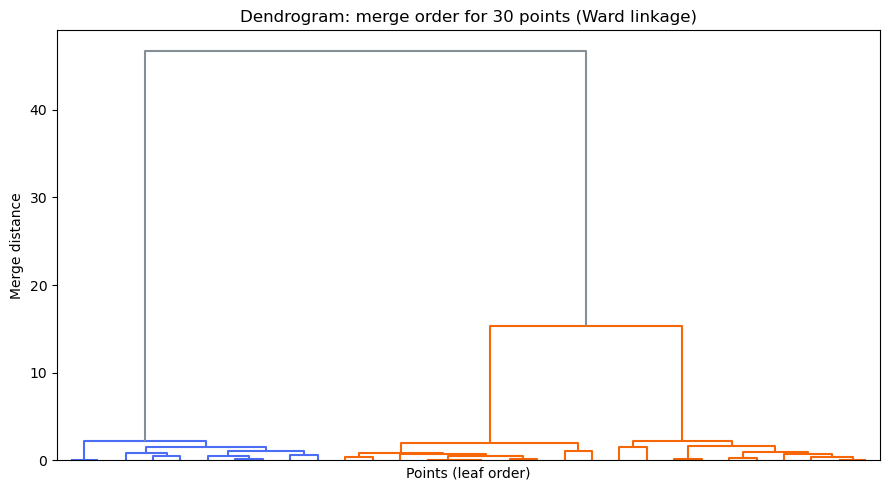

In [2]:
np.random.seed(11)
X_dendro, _ = make_blobs(n_samples=30, centers=3, cluster_std=0.6, random_state=11)
Z_dendro = linkage(X_dendro, method='ward')

set_link_color_palette([PALETTE['primary'], PALETTE['secondary'], PALETTE['accent'], PALETTE['muted']])

fig, ax = plt.subplots(figsize=(9, 5))
dendrogram(Z_dendro, ax=ax, color_threshold=0.7 * max(Z_dendro[:, 2]),
           above_threshold_color=PALETTE['muted'])
ax.set_title('Dendrogram: merge order for 30 points (Ward linkage)')
ax.set_xlabel('Points (leaf order)')
ax.set_ylabel('Merge distance')
ax.set_xticks([])
plt.tight_layout()
plt.show()


---
## What's happening?

The dendrogram records every merge in the hierarchy. The height of each horizontal line shows the distance between the two clusters being merged at that step. Long vertical lines below a horizontal merge line mean those clusters were far apart — those are the "natural" boundaries.

Choosing a cut height is choosing which merges to "undo." Cut low: many small clusters. Cut high: few large clusters. The standard heuristic is to cut at the largest vertical gap — the place where the algorithm jumps the most distance to make the next merge.

Ward linkage almost always produces the most useful dendrograms for compact, roughly-spherical clusters. Use single linkage when you care about detecting chains or outliers.

In [3]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)
X, _ = make_blobs(n_samples=150, centers=4, cluster_std=0.60, random_state=42)
X_sc = StandardScaler().fit_transform(X)

# Fit with sklearn
model = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels = model.fit_predict(X_sc)
print(f'Cluster sizes: {np.bincount(labels)}')

# Build dendrogram data with scipy
Z = linkage(X_sc, method='ward')
print(f'Linkage matrix shape: {Z.shape}  (n-1 merges for {len(X_sc)} points)')

Cluster sizes: [37 38 38 37]
Linkage matrix shape: (149, 4)  (n-1 merges for 150 points)


---
## Real-world example: Applying the Cut

After building the dendrogram, you pick a cut height and get concrete clusters back. Cutting the same Ward-linkage tree at 4 clusters on 150 points produces the groups below.

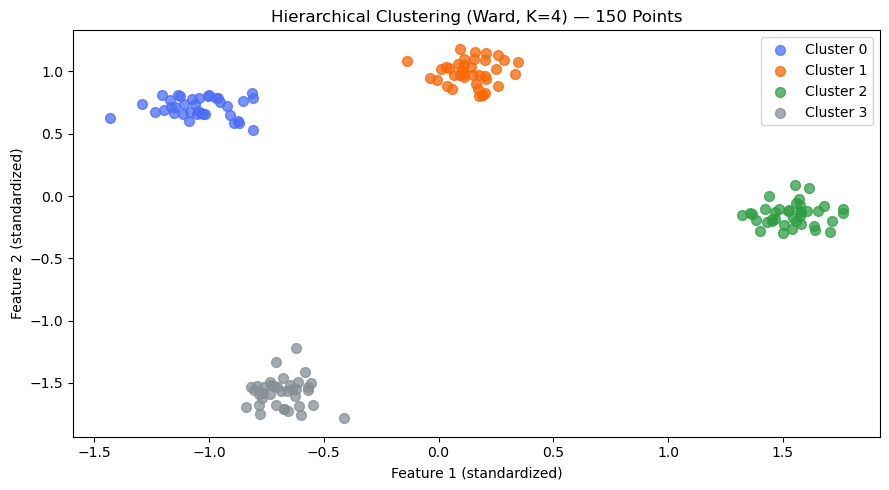

In [4]:
np.random.seed(42)
X, _ = make_blobs(n_samples=150, centers=4, cluster_std=0.60, random_state=42)
X_sc = StandardScaler().fit_transform(X)
Z = linkage(X_sc, method='ward')

model = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels = model.fit_predict(X_sc)

cluster_colors = [PALETTE['primary'], PALETTE['secondary'], PALETTE['accent'], PALETTE['muted']]
fig, ax = plt.subplots(figsize=(9, 5))
for k in range(4):
    mask = labels == k
    ax.scatter(X_sc[mask, 0], X_sc[mask, 1], color=cluster_colors[k], s=50, alpha=0.75, label=f'Cluster {k}')
ax.set_title('Hierarchical Clustering (Ward, K=4) — 150 Points')
ax.set_xlabel('Feature 1 (standardized)')
ax.set_ylabel('Feature 2 (standardized)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Key hyperparameters

**`n_clusters`** (required in sklearn): Number of clusters to return. Or use `distance_threshold` to cut the tree at a height instead of specifying K.

**`linkage`** (default `'ward'`): How inter-cluster distance is computed. `'ward'` (minimize WCSS increase) is almost always the best starting point.

**`metric`** (default `'euclidean'`): Distance metric. With `linkage='ward'`, only Euclidean is supported.

sklearn docs: [sklearn.cluster.AgglomerativeClustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

---
## Real-world example: Applying the Cut

After building the dendrogram, you pick a cut height and get concrete clusters back. Cutting the same Ward-linkage tree at 4 clusters on 150 points produces the groups below.

---
## Strengths and weaknesses

| Strength | Weakness |
|----------|----------|
| No need to specify K in advance | O(n²) or O(n³) memory and time — does not scale |
| Dendrogram reveals cluster hierarchy at every level | Cannot reassign points after initial merge |
| Deterministic — same data always gives same tree | Sensitive to outliers (especially single linkage) |
| Linkage choice gives flexibility for different cluster shapes | Cannot handle new data without rebuilding the tree |
| Rich visualization via dendrogram | Ward linkage limited to Euclidean distance |

---
## Key takeaway

> **Hierarchical clustering solves the K-selection problem by building a complete tree of every possible grouping at once — the dendrogram lets you choose the granularity that makes sense for your problem after you see the structure.**

---
*Next up: 05_dbscan — where clusters are defined by density, not distance to a centroid, and outliers are automatically identified*